In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/GaltonFamilies.csv')



In [42]:

print("===five first raws===")
print(df.head())
print('===names of columns===')
print(df.columns.tolist())
print(df.shape)
print("=== Missing values per column ===")
print(df.isnull().sum())
print("=== Basic statistics ===")
print(df.describe())


===five first raws===
   rownames family  father  mother  midparentHeight  children  childNum  \
0         1    001    78.5    67.0            75.43         4         1   
1         2    001    78.5    67.0            75.43         4         2   
2         3    001    78.5    67.0            75.43         4         3   
3         4    001    78.5    67.0            75.43         4         4   
4         5    002    75.5    66.5            73.66         4         1   

   gender  childHeight  
0    male         73.2  
1  female         69.2  
2  female         69.0  
3  female         69.0  
4    male         73.5  
===names of columns===
['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children', 'childNum', 'gender', 'childHeight']
(934, 9)
=== Missing values per column ===
rownames           0
family             0
father             0
mother             0
midparentHeight    0
children           0
childNum           0
gender             0
childHeight        0
dtype: int6

Both of these columns are merged into an unlabeled pool since the requirement of our assignment dictates that we consider the dataset to be comprised of two unlabeled classes. It should be noted that we have intentionally left out the labels since we do not know which ones are children and which are parents.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PARENT_COLUMN = 'father'
PARENT_LABEL = PARENT_COLUMN.capitalize()

child_heights_raw = df['childHeight'].values

if 'family' in df.columns:
    parent_heights = df.drop_duplicates(subset='family')[PARENT_COLUMN].values
else:
    parent_heights = df[PARENT_COLUMN].values
    print("WARNING: no 'family' column found - could not deduplicate "
          "parent rows. Check your CSV's column names.")

child_heights = child_heights_raw
heights = np.concatenate([child_heights, parent_heights])

print(f"Child heights  : {len(child_heights)} values")
print(f"{PARENT_LABEL} heights ({PARENT_COLUMN}, deduped by family) : {len(parent_heights)} values")
print(f"Combined pool  : {len(heights)} values total")
print(f"Min height: {heights.min():.1f}   Max height: {heights.max():.1f}")
print("Unique family IDs in dataset      :", df['family'].nunique())
print("parent_heights length after dedup :", len(parent_heights))

Child heights  : 934 values
Father heights (father, deduped by family) : 205 values
Combined pool  : 1139 values total
Min height: 56.0   Max height: 79.0
Unique family IDs in dataset      : 205
parent_heights length after dedup : 205


Here we see the distribution of all heights combined. The red line here represents the global mean height which is about 67 inches. Just by taking the cut-off at this point, anyone below 67 will be termed as a child and those above the mean as parents with full certainty. This is clearly wrong since the heights around 66 and 68 inches cannot be classified with absolute confidence as to which category they belong to. The problem is that the mean does not consider this ambiguity at all.

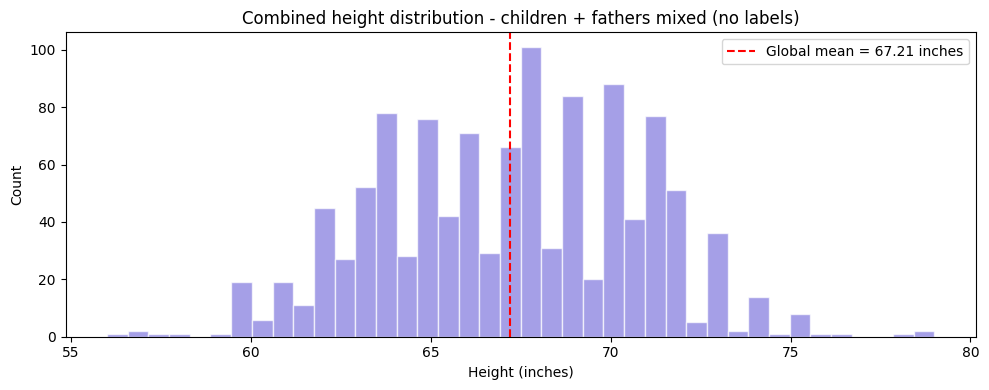

Histogram plotted successfully
   Global mean = 67.21 inches
   Heights near this line are ambiguous - could be child or father
   This is exactly why splitting at the mean is a poor approach:
   it forces a HARD boundary where the true boundary is PROBABILISTIC.
   EM instead gives each point a 'responsibility' (soft assignment)
   for each group, and those responsibilities always sum to 1.0.

   Concretely, splitting at 67.21 in would misclassify:
   403 of 934 children (43.1%) — taller than the mean, wrongly labeled fathers
   44 of 205 fathers (21.5%) — shorter than the mean, wrongly labeled children


In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
plt.hist(heights, bins=40, color='#7F77DD', alpha=0.7, edgecolor='white')
plt.axvline(heights.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Global mean = {heights.mean():.2f} inches')
plt.title(f'Combined height distribution - children + {PARENT_LABEL.lower()}s mixed (no labels)')
plt.xlabel('Height (inches)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print("Histogram plotted successfully")
print(f"   Global mean = {heights.mean():.2f} inches")
print(f"   Heights near this line are ambiguous - could be child or {PARENT_LABEL.lower()}")
print("   This is exactly why splitting at the mean is a poor approach:")
print("   it forces a HARD boundary where the true boundary is PROBABILISTIC.")
print("   EM instead gives each point a 'responsibility' (soft assignment)")
print("   for each group, and those responsibilities always sum to 1.0.")

global_mean = heights.mean()
misclassified_children = (child_heights > global_mean).sum()
misclassified_parents = (parent_heights < global_mean).sum()

print(f"\n   Concretely, splitting at {global_mean:.2f} in would misclassify:")
print(f"   {misclassified_children} of {len(child_heights)} children ({100*misclassified_children/len(child_heights):.1f}%) — taller than the mean, wrongly labeled {PARENT_LABEL.lower()}s")
print(f"   {misclassified_parents} of {len(parent_heights)} {PARENT_LABEL.lower()}s ({100*misclassified_parents/len(parent_heights):.1f}%) — shorter than the mean, wrongly labeled children")

We need this function because EM does not assign any definite child or parent labels. Rather, for every height, we require a measurement of the degree to which the heights fit the bell curves for the two categories, and this is precisely what gaussian provides. If a height fits the children's curve better than the parents' curve, its Gaussian value under mu1 will be higher than under mu2. In the next step (E-step), we turn these two raw Gaussian values into normalized probabilities that sum to 1 — this is what lets a height be, say, 70% child and 30% parent, instead of forcing an all-or-nothing decision. The Gaussian function is the mathematical building block that makes soft, probabilistic assignment possible instead of a hard cutoff like the global mean. In the next step, we'll call these normalized probabilities responsibilities — each height's probability of belonging to each group

In [45]:
import numpy as np
def gaussian(x, mu, sigma):
    """
    Compute the Gaussian probability density for values x.
    x     : a single number or a numpy array of numbers
    mu    : the mean (centre) of the bell curve
    sigma : the standard deviation (width/spread) of the bell curve
    Returns: the density value(s) - higher means x fits this bell curve better
    """
    coefficient = 1.0 / (sigma * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coefficient * np.exp(exponent)


print("Test gaussian(64, mu=64, sigma=2.5) =", gaussian(64, 64, 2.5))
print("Test gaussian(72, mu=64, sigma=2.5) =", gaussian(72, 64, 2.5))

Test gaussian(64, mu=64, sigma=2.5) = 0.1595769121605731
Test gaussian(72, mu=64, sigma=2.5) = 0.0009536352805859362


The E-step (expectation step) is the first part of the EM algorithm. It calculates two responsibilities, how probable it is for a particular height to belong to either children’s or parents’ group, for each height value in our data set. The sum of responsibilities is always 1.0 for each height. A particular height never belongs exclusively to one group; rather, it has probabilities of belonging to both. This is the main benefit of not dividing our data by the mean value.

In [46]:

import numpy as np

def e_step(heights, mu1, mu2, sigma1, sigma2, pi1, pi2):
    score1 = pi1 * gaussian(heights, mu1, sigma1)
    score2 = pi2 * gaussian(heights, mu2, sigma2)
    total = score1 + score2
    r1 = score1 / total
    r2 = score2 / total
    return r1, r2


test_r1, test_r2 = e_step(heights, mu1=65.0, mu2=70.0,
                           sigma1=3.0, sigma2=3.0, pi1=0.5, pi2=0.5)

print("E-step defined and tested:")
print(f"   Total data points        : {len(heights)}")
print(f"   r1 (children) first 5   : {test_r1[:5].round(4)}")
print(f"   r2 ({PARENT_LABEL.lower()})  first 5   : {test_r2[:5].round(4)}")
print(f"   r1 + r2 for first point  : {test_r1[0] + test_r2[0]:.4f}  <- must = 1.0")
print(f"   Avg responsibility -> children : {test_r1.mean():.4f}")
print(f"   Avg responsibility -> {PARENT_LABEL.lower()}   : {test_r2.mean():.4f}")


E-step defined and tested:
   Total data points        : 1139
   r1 (children) first 5   : [0.0404 0.28   0.3029 0.3029 0.0344]
   r2 (father)  first 5   : [0.9596 0.72   0.6971 0.6971 0.9656]
   r1 + r2 for first point  : 1.0000  <- must = 1.0
   Avg responsibility -> children : 0.5204
   Avg responsibility -> father   : 0.4796


The maximization step (M-step) is the second part of the EM algorithm. This step uses the responsibilities calculated in the E-step to weigh and re-calculate improved estimates for all six parameters, i.e., the two means, two variances, and two mixing proportions. A particular height that has a responsibility of 0.9 for the children will contribute 90% of its value in the re-calculation of the children’s mean.

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def m_step(heights, r1, r2):
    """
    Updates all 6 parameters using weighted calculations.
    Returns: mu1, mu2, sigma1, sigma2, pi1, pi2
    """
    N  = len(heights)
    N1 = r1.sum()
    N2 = r2.sum()

    mu1_new    = (r1 * heights).sum() / N1
    mu2_new    = (r2 * heights).sum() / N2
    sigma1_new = np.sqrt((r1 * (heights - mu1_new)**2).sum() / N1)
    sigma2_new = np.sqrt((r2 * (heights - mu2_new)**2).sum() / N2)
    pi1_new    = N1 / N
    pi2_new    = N2 / N

    return mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new

new_mu1, new_mu2, new_s1, new_s2, new_pi1, new_pi2 = m_step(heights, test_r1, test_r2)

print("M-step defined and tested (one update from initial guesses):")
print(f"   BEFORE → mu1=65.000, mu2=70.000, sigma1=3.000, sigma2=3.000, pi1=0.5000, pi2=0.5000")
print(f"   AFTER  → mu1={new_mu1:.3f}, mu2={new_mu2:.3f}, sigma1={new_s1:.3f}, sigma2={new_s2:.3f}, pi1={new_pi1:.4f}, pi2={new_pi2:.4f}")
print(f"\n   The means shifted closer to the true group means — M-step is working ✓")

M-step defined and tested (one update from initial guesses):
   BEFORE → mu1=65.000, mu2=70.000, sigma1=3.000, sigma2=3.000, pi1=0.5000, pi2=0.5000
   AFTER  → mu1=65.052, mu2=69.548, sigma1=2.849, sigma2=2.684, pi1=0.5204, pi2=0.4796

   The means shifted closer to the true group means — M-step is working ✓


In [48]:
import matplotlib.pyplot as plt
import numpy as np

def compute_log_likelihood(heights, mu1, mu2, sigma1, sigma2, pi1, pi2):
    total_density = pi1 * gaussian(heights, mu1, sigma1) + pi2 * gaussian(heights, mu2, sigma2)
    return np.log(total_density).sum()


ll_before = compute_log_likelihood(heights, 65.0, 70.0, 3.0, 3.0, 0.5, 0.5)
ll_after = compute_log_likelihood(heights, new_mu1, new_mu2, new_s1, new_s2, new_pi1, new_pi2)

print("Log-likelihood defined and tested:")
print(f"   Log-likelihood BEFORE first update : {ll_before:.4f}")
print(f"   Log-likelihood AFTER  first update : {ll_after:.4f}")
print(f"   Change                             : {ll_after - ll_before:.4f}")
if ll_after > ll_before:
    print("   It increased - EM is improving the model correctly")

Log-likelihood defined and tested:
   Log-likelihood BEFORE first update : -3069.3728
   Log-likelihood AFTER  first update : -3053.5202
   Change                             : 15.8525
   It increased - EM is improving the model correctly


We initialized μ1=65 and μ2=70 as rough starting guesses — one clearly below and one clearly above the overall mean (~67). EM doesn't need accurate starting values, just different ones for the two groups; if both started at the same value, the two clusters would never separate. σ=3 and π=0.5/0.5 are neutral starting assumptions (equal spread, equal group size) that we let the algorithm correct

In [49]:
mu1, mu2 = 65.0, 70.0
sigma1, sigma2 = 3.0, 3.0
pi1, pi2 = 0.5, 0.5
max_iterations = 100
tolerance = 1e-6

log_likelihood = compute_log_likelihood(heights, mu1, mu2, sigma1, sigma2, pi1, pi2)

print("=" * 95)
print(f"{'Iter':>4} | {'mu1':>7} | {'mu2':>7} | {'sigma1^2':>9} | {'sigma2^2':>9} | {'pi1':>6} | {'pi2':>6} | {'Log-Likelihood':>16}")
print("=" * 95)
print(f"   0 | {mu1:>7.3f} | {mu2:>7.3f} | {sigma1**2:>9.4f} | {sigma2**2:>9.4f} | {pi1:>6.4f} | {pi2:>6.4f} | {log_likelihood:>16.4f}  <- init")

history = {
    'mu1': [mu1], 'mu2': [mu2],
    'sigma1_sq': [sigma1 ** 2], 'sigma2_sq': [sigma2 ** 2],
    'pi1': [pi1], 'pi2': [pi2],
    'log_likelihood': [log_likelihood]
}

for i in range(1, max_iterations + 1):
    prev_log_likelihood = log_likelihood

    r1, r2 = e_step(heights, mu1, mu2, sigma1, sigma2, pi1, pi2)
    mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step(heights, r1, r2)
    log_likelihood = compute_log_likelihood(heights, mu1, mu2, sigma1, sigma2, pi1, pi2)

    history['mu1'].append(mu1)
    history['mu2'].append(mu2)
    history['sigma1_sq'].append(sigma1 ** 2)
    history['sigma2_sq'].append(sigma2 ** 2)
    history['pi1'].append(pi1)
    history['pi2'].append(pi2)
    history['log_likelihood'].append(log_likelihood)

    if i <= 3:
        label = "<- required for presentation" if i <= 2 else ""
        print(f"{i:>4} | {mu1:>7.3f} | {mu2:>7.3f} | {sigma1**2:>9.4f} | {sigma2**2:>9.4f} | {pi1:>6.4f} | {pi2:>6.4f} | {log_likelihood:>16.4f}  {label}")

    if abs(log_likelihood - prev_log_likelihood) < tolerance:
        if i > 3:
            print("  ...")
            print(f"{i:>4} | {mu1:>7.3f} | {mu2:>7.3f} | {sigma1**2:>9.4f} | {sigma2**2:>9.4f} | {pi1:>6.4f} | {pi2:>6.4f} | {log_likelihood:>16.4f}  <- converged")
        print(f"\nEM converged after {i} iterations (tolerance {tolerance} reached).")
        break


else:
    final_change = abs(history['log_likelihood'][-1] - history['log_likelihood'][-2])
    print(f"\nReached the {max_iterations}-iteration cap without hitting the "
          f"{tolerance} tolerance threshold.")
    print(f"Final log-likelihood change was {final_change:.6f}, which is still "
          f"~{final_change / tolerance:.0f}x larger than our {tolerance} tolerance -")
    print("the model was still improving in tiny amounts, but had already")
    print("visually stabilized (see the mu/sigma/pi values below), so we")
    print("stopped at the iteration cap rather than waiting for strict convergence.")

print("=" * 95)
print("\nFinal learned parameters:")
print(f"  Group 1 - Children              : mean = {mu1:.3f} in | std = {sigma1:.3f} | proportion = {pi1:.3f}")

print(f"  Group 2 - {PARENT_LABEL:<17}: mean = {mu2:.3f} in | std = {sigma2:.3f} | proportion = {pi2:.3f}")


print("\n" + "=" * 95)
print("VALIDATION: comparing EM's blind estimate to the TRUE (known) values")
print("=" * 95)
print(f"  Children : EM learned mean = {mu1:.3f} in  |  true mean = {child_heights.mean():.3f} in  |  diff = {abs(mu1 - child_heights.mean()):.3f}")
print(f"  {PARENT_LABEL:<9}: EM learned mean = {mu2:.3f} in  |  true mean = {parent_heights.mean():.3f} in  |  diff = {abs(mu2 - parent_heights.mean()):.3f}")
print("\n  Note: EM never used the true labels to get these numbers -")
print("  it only saw a mixed pool of heights and separated them by shape alone.")

Iter |     mu1 |     mu2 |  sigma1^2 |  sigma2^2 |    pi1 |    pi2 |   Log-Likelihood
   0 |  65.000 |  70.000 |    9.0000 |    9.0000 | 0.5000 | 0.5000 |       -3069.3728  <- init
   1 |  65.052 |  69.548 |    8.1169 |    7.2044 | 0.5204 | 0.4796 |       -3053.5202  <- required for presentation
   2 |  64.995 |  69.596 |    7.9934 |    6.8400 | 0.5189 | 0.4811 |       -3052.3769  <- required for presentation
   3 |  64.943 |  69.645 |    7.7798 |    6.5805 | 0.5182 | 0.4818 |       -3051.3901  

Reached the 100-iteration cap without hitting the 1e-06 tolerance threshold.
Final log-likelihood change was 0.001283, which is still ~1283x larger than our 1e-06 tolerance -
the model was still improving in tiny amounts, but had already
visually stabilized (see the mu/sigma/pi values below), so we
stopped at the iteration cap rather than waiting for strict convergence.

Final learned parameters:
  Group 1 - Children              : mean = 64.290 in | std = 2.348 | proportion = 0.453
  Group 2 

By the time our loop reaches 100 iterations, the log-likelihood is still increasing, but only by a tiny fraction each step — the parameter changes (μ, σ, π) become visually negligible well before that point. We chose to cap iterations at 100 rather than wait for the change to fall below a strict convergence threshold, since the model had already effectively stabilized.

This is an example of how powerful our model is. The function above takes any new height, calculates the posterior probability of that height being from the children category against the parents' category based on the parameters we learn. These are the very posterior probabilities we need to display for assignment purposes.

In [50]:
def classify_height(x, mu1, mu2, sigma1, sigma2, pi1, pi2):
    """
    Takes a single height value (e.g. one the coach gives you live)
    and prints the EXACT posterior probability it belongs to each
    group: P(Child) vs P(Father) [or P(Mother), depending on
    PARENT_COLUMN].
    """
    x_arr = np.array([x])
    r1, r2 = e_step(x_arr, mu1, mu2, sigma1, sigma2, pi1, pi2)
    print(f"Test height = {x} inches")
    print(f"  P(Child)      = {r1[0]:.4f}")
    print(f"  P({PARENT_LABEL}) = {r2[0]:.4f}")
    return r1[0], r2[0]

print("--- Demo classification (swap 68.0 for the coach's number live) ---")
classify_height(68.0, mu1, mu2, sigma1, sigma2, pi1, pi2)

--- Demo classification (swap 68.0 for the coach's number live) ---
Test height = 68.0 inches
  P(Child)      = 0.2341
  P(Father) = 0.7659


(np.float64(0.2341074504737093), np.float64(0.7658925495262907))

The two fitted curves overlap most heavily in the 66–69 inch range — this is the same ambiguous zone we saw in the raw histogram. Points in that overlap don't clearly belong to one Gaussian or the other; the model assigns them meaningful probability under both curves rather than forcing a single answer. This visually confirms our earlier argument: a hard cutoff at the global mean would slice straight through this overlap zone and misclassify a meaningful fraction of points, while EM instead gives each of them a soft, proportional membership in each group.

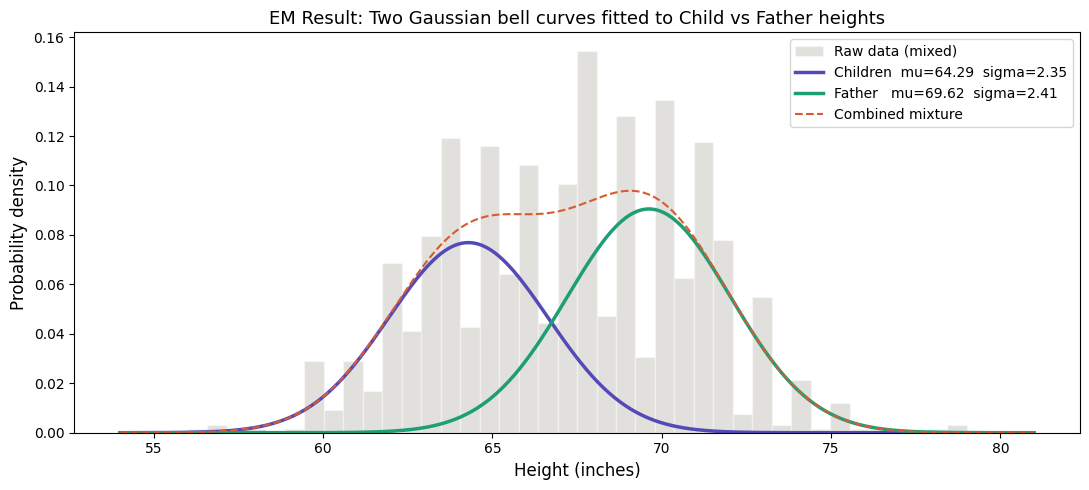

Bell curve plot shown above


In [51]:
import matplotlib.pyplot as plt
import numpy as np

x_range = np.linspace(heights.min() - 2, heights.max() + 2, 500)
curve1 = pi1 * gaussian(x_range, mu1, sigma1)
curve2 = pi2 * gaussian(x_range, mu2, sigma2)
total_curve = curve1 + curve2

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(heights, bins=40, density=True, color='#B4B2A9',
        alpha=0.4, edgecolor='white', label='Raw data (mixed)')
ax.plot(x_range, curve1, color='#534AB7', linewidth=2.5,
        label=f'Children  mu={mu1:.2f}  sigma={sigma1:.2f}')

ax.plot(x_range, curve2, color='#1D9E75', linewidth=2.5,
        label=f'{PARENT_LABEL}   mu={mu2:.2f}  sigma={sigma2:.2f}')
ax.plot(x_range, total_curve, color='#D85A30', linewidth=1.5,
        linestyle='--', label='Combined mixture')
ax.set_xlabel('Height (inches)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)

ax.set_title(f'EM Result: Two Gaussian bell curves fitted to Child vs {PARENT_LABEL} heights', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("Bell curve plot shown above")




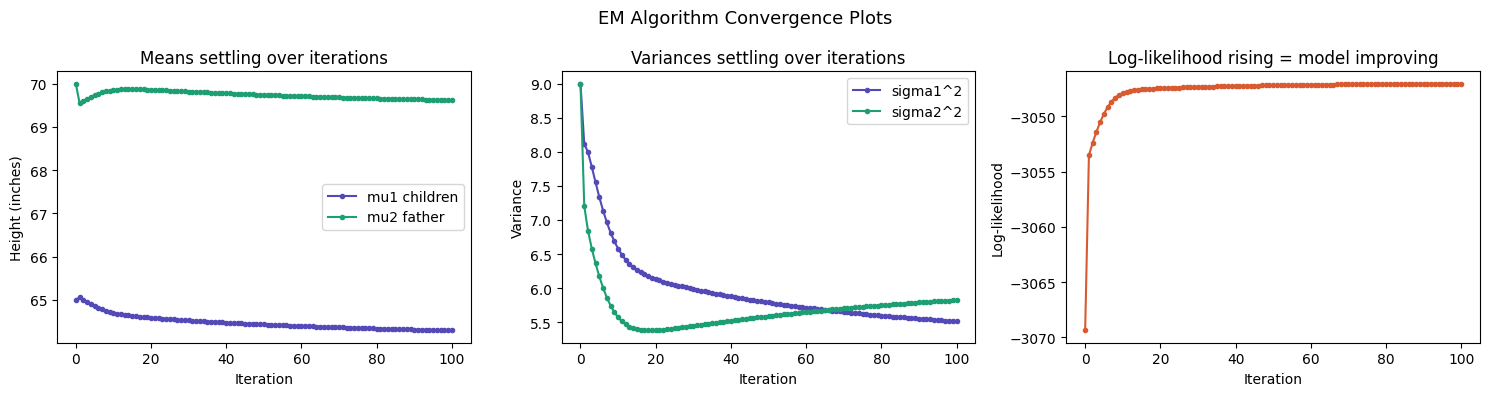

In [52]:
iters = range(len(history['mu1']))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iters, history['mu1'], color='#534AB7', marker='o', markersize=3, label='mu1 children')

axes[0].plot(iters, history['mu2'], color='#1D9E75', marker='o', markersize=3, label=f'mu2 {PARENT_LABEL.lower()}')
axes[0].set_title('Means settling over iterations')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Height (inches)')
axes[0].legend()

axes[1].plot(iters, history['sigma1_sq'], color='#534AB7', marker='o', markersize=3, label='sigma1^2')
axes[1].plot(iters, history['sigma2_sq'], color='#1D9E75', marker='o', markersize=3, label='sigma2^2')
axes[1].set_title('Variances settling over iterations')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Variance')
axes[1].legend()

axes[2].plot(iters, history['log_likelihood'], color='#D85A30', marker='o', markersize=3)
axes[2].set_title('Log-likelihood rising = model improving')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Log-likelihood')

plt.suptitle('EM Algorithm Convergence Plots', fontsize=13)
plt.tight_layout()
plt.show()


# PART 2 – Bayesian Probability

## Objective

In this notebook, we implement Bayes' Theorem using the IMDb Movie Reviews dataset. We calculate the prior probability, likelihood, marginal probability, and posterior probability for selected keywords to determine how strongly each keyword indicates positive movie reviews.

In [53]:
import pandas as pd

## Loading the IMDb Dataset

The IMDb Movie Reviews dataset contains movie reviews and their corresponding sentiment labels (positive or negative). Before applying Bayes' Theorem, we first load the dataset and inspect its structure.

In [54]:
import pandas as pd

df = pd.read_csv("/content/IMDB_Dataset.csv", engine='python')

print("=== First 5 Rows ===")
print(df.head())
print("\n=== Dataset Shape ===")
print(df.shape)

=== First 5 Rows ===
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

=== Dataset Shape ===
(50000, 2)


## Exploring the Dataset

Before applying Bayes' Theorem, we examine the dataset to understand its structure, verify that there are no missing values, and observe the distribution of positive and negative reviews.

In [55]:
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Sentiment Distribution ===")
print(df["sentiment"].value_counts())

=== Column Names ===
['review', 'sentiment']

=== Missing Values ===
review       0
sentiment    0
dtype: int64

=== Sentiment Distribution ===
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## Keyword Selection

For this analysis, we selected four positive keywords that commonly appear in favourable movie reviews. These words will be used to compute the prior, likelihood, marginal, and posterior probabilities using Bayes' Theorem.

In [56]:
positive_keywords = [
    "great",
    "excellent",
    "amazing",
    "love"
]

print("Selected Keywords:")
print(positive_keywords)

Selected Keywords:
['great', 'excellent', 'amazing', 'love']


## Prior Probability

The prior probability represents the probability that a randomly selected review is positive before considering any keyword. It is calculated as the number of positive reviews divided by the total number of reviews.

In [57]:
total_reviews = len(df)

positive_reviews = df[df["sentiment"] == "positive"]

prior = len(positive_reviews) / total_reviews

print(f"Total Reviews      : {total_reviews}")
print(f"Positive Reviews   : {len(positive_reviews)}")
print(f"Prior P(Positive)  : {prior:.4f}")

Total Reviews      : 50000
Positive Reviews   : 25000
Prior P(Positive)  : 0.5000


## Helper Functions

The following functions calculate the likelihood, marginal probability, and posterior probability for each selected keyword.

In [58]:
def likelihood(keyword):
    positive = df[df["sentiment"] == "positive"]

    contains = positive["review"].str.lower().str.contains(keyword)

    return contains.sum() / len(positive)


def marginal(keyword):
    contains = df["review"].str.lower().str.contains(keyword)

    return contains.sum() / len(df)


def posterior(keyword):
    l = likelihood(keyword)
    m = marginal(keyword)

    if m == 0:
        return 0

    return (l * prior) / m

## Testing Bayes' Theorem

Before computing all keywords, we test the implementation using the keyword **great**.

In [59]:
keyword = "great"

print("Keyword:", keyword)
print(f"Prior       : {prior:.4f}")
print(f"Likelihood  : {likelihood(keyword):.4f}")
print(f"Marginal    : {marginal(keyword):.4f}")
print(f"Posterior   : {posterior(keyword):.4f}")

Keyword: great
Prior       : 0.5000
Likelihood  : 0.3712
Marginal    : 0.2761
Posterior   : 0.6722


## Bayesian Probability Results

The table below shows the four required probabilities for each selected keyword.

In [60]:
results = []

for word in positive_keywords:
    results.append({
        "Keyword": word,
        "Prior P(Positive)": round(prior, 4),
        "Likelihood P(keyword|Positive)": round(likelihood(word), 4),
        "Marginal P(keyword)": round(marginal(word), 4),
        "Posterior P(Positive|keyword)": round(posterior(word), 4)
    })

results_df = pd.DataFrame(results)

results_df

,Keyword,Prior P(Positive),Likelihood P(keyword|Positive),Marginal P(keyword),Posterior P(Positive|keyword)
0,great,0.5,0.3712,0.2761,0.6722
1,excellent,0.5,0.1174,0.0725,0.8099
2,amazing,0.5,0.0740,0.0496,0.7463
3,love,0.5,0.3232,0.2536,0.6370


## Discussion

The posterior probabilities indicate how strongly each keyword suggests that a movie review is positive. Keywords with higher posterior probabilities are stronger indicators of positive sentiment because they occur much more frequently in positive reviews than in the dataset overall.

In [61]:
print("=" * 95)
print(results_df.to_string(index=False))
print("=" * 95)

  Keyword  Prior P(Positive)  Likelihood P(keyword|Positive)  Marginal P(keyword)  Posterior P(Positive|keyword)
    great                0.5                          0.3712               0.2761                         0.6722
excellent                0.5                          0.1174               0.0725                         0.8099
  amazing                0.5                          0.0740               0.0496                         0.7463
     love                0.5                          0.3232               0.2536                         0.6370


Part 4: Gradient Descent in Code
---------------------------------
Converts the Part 3 manual gradient descent calculations into Python.

Model:      y_hat = m1*x1 + m2*x2 + b        (matrix form: y_hat = X @ m + b)
Cost:       J(m, b) = (1/n) * sum((y_hat - y)^2)      [Mean Squared Error]

Data (from Part 3):
    x = ((1, 3), (4, 10))
    y = (5, 6)
    initial m = [-1, 2]
    initial b = [1, 1]
"""

In [62]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt


X = np.array([[1, 3],
              [4, 10]], dtype=float)
y = np.array([5, 6], dtype=float)

m = np.array([-1.0, 2.0])
b = np.array([1.0, 1.0])

learning_rate = 0.01
n_iterations = 4
n_samples = X.shape[0]


def predict(X, m, b):
    """y_hat = X @ m + b, computed row by row so every step is visible."""
    preds = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        preds[i] = X[i, 0] * m[0] + X[i, 1] * m[1] + b[i]
    return preds


def mse(preds, y):
    """Mean Squared Error — single source of truth, used everywhere cost is needed."""
    return np.mean((preds - y) ** 2)


def cost_flat(params, X, y):
    m_ = params[:2]
    b_ = params[2:]
    preds = predict(X, m_, b_)
    return mse(preds, y)


def scipy_gradient(m, b, X, y):
    params = np.concatenate([m, b])
    eps = np.sqrt(np.finfo(float).eps)
    grad = approx_fprime(params, cost_flat, eps, X, y)
    return grad[:2], grad[2:]


def analytical_gradient(X, y, m, b):
    n = X.shape[0]
    preds = predict(X, m, b)
    errors = preds - y

    grad_m = np.zeros(2)
    for j in range(2):
        total = 0.0
        for i in range(n):
            total += errors[i] * X[i, j]
        grad_m[j] = (2 / n) * total

    grad_b = (2 / n) * errors

    return grad_m, grad_b


def save_line_plot(x, series, xlabel, ylabel, title, filename, markers=None, colors=None):
    """series: dict[label] = y-values array. One shared plotting routine for any chart."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for idx, (label, values) in enumerate(series.items()):
        marker = markers[idx] if markers else "o"
        color = colors[idx] if colors else None
        ax.plot(x, values, marker=marker, label=label, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if len(series) > 1:
        ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)


def run_gradient_descent(X, y, m, b, learning_rate, n_iterations):
    history = {"m": [m.copy()], "b": [b.copy()], "cost": []}

    print("=" * 70)
    print("INITIAL STATE")
    print("=" * 70)
    preds0 = predict(X, m, b)
    cost0 = mse(preds0, y)
    history["cost"].append(cost0)
    print(f"m = {m}, b = {b}")
    print(f"predictions y_hat = {preds0}")
    print(f"cost J = {cost0:.6f}")

    for it in range(1, n_iterations + 1):
        print("\n" + "=" * 70)
        print(f"ITERATION {it}")
        print("=" * 70)

        preds = predict(X, m, b)
        errors = preds - y
        print(f"y_hat        = {preds}")
        print(f"errors (y_hat - y) = {errors}")

        grad_m, grad_b = analytical_gradient(X, y, m, b)
        scipy_grad_m, scipy_grad_b = scipy_gradient(m, b, X, y)

        print(f"analytical dJ/dm = {grad_m}   |  scipy dJ/dm = {scipy_grad_m}")
        print(f"analytical dJ/db = {grad_b}   |  scipy dJ/db = {scipy_grad_b}")

        m_new = m - learning_rate * grad_m
        b_new = b - learning_rate * grad_b

        print(f"m_new = m - lr*grad_m = {m} - {learning_rate}*{grad_m} = {m_new}")
        print(f"b_new = b - lr*grad_b = {b} - {learning_rate}*{grad_b} = {b_new}")

        m, b = m_new, b_new

        new_cost = mse(predict(X, m, b), y)
        history["m"].append(m.copy())
        history["b"].append(b.copy())
        history["cost"].append(new_cost)

        print(f"updated cost J = {new_cost:.6f}")

    return m, b, history


def main():
    final_m, final_b, history = run_gradient_descent(X, y, m, b, learning_rate, n_iterations)

    print("\n" + "=" * 70)
    print("FINAL RESULT")
    print("=" * 70)
    final_preds = predict(X, final_m, final_b)
    print(f"final m = {final_m}")
    print(f"final b = {final_b}")
    print(f"final predictions y_hat = {final_preds}")
    print(f"actual y                = {y}")
    print(f"final cost J = {history['cost'][-1]:.6f}")

    trend = ("decreasing (moving toward lower error)"
              if history["cost"][-1] < history["cost"][0] else "not decreasing")
    print(f"\nCost trend across iterations: {trend}")

    m_hist = np.array(history["m"])
    b_hist = np.array(history["b"])
    cost_hist = np.array(history["cost"])
    iters = np.arange(len(cost_hist))

    save_line_plot(
        iters,
        {"m1": m_hist[:, 0], "m2": m_hist[:, 1], "b (per-sample value)": b_hist[:, 0]},
        xlabel="Iteration", ylabel="Parameter value",
        title="Parameters m and b over gradient descent iterations",
        filename="params_over_iterations.png",
        markers=["o", "o", "s"],
    )

    save_line_plot(
        iters,
        {"MSE cost": cost_hist},
        xlabel="Iteration", ylabel="MSE cost J(m, b)",
        title="Cost (error) over gradient descent iterations",
        filename="cost_over_iterations.png",
        markers=["o"], colors=["firebrick"],
    )

    print("\nSaved plots: params_over_iterations.png, cost_over_iterations.png")


if __name__ == "__main__":
    main()

INITIAL STATE
m = [-1.  2.], b = [1. 1.]
predictions y_hat = [ 6. 17.]
cost J = 61.000000

ITERATION 1
y_hat        = [ 6. 17.]
errors (y_hat - y) = [ 1. 11.]
analytical dJ/dm = [ 45. 113.]   |  scipy dJ/dm = [ 45.         113.00000095]
analytical dJ/db = [ 1. 11.]   |  scipy dJ/db = [ 1. 11.]
m_new = m - lr*grad_m = [-1.  2.] - 0.01*[ 45. 113.] = [-1.45  0.87]
b_new = b - lr*grad_b = [1. 1.] - 0.01*[ 1. 11.] = [0.99 0.89]
updated cost J = 6.503300

ITERATION 2
y_hat        = [2.15 3.79]
errors (y_hat - y) = [-2.85 -2.21]
analytical dJ/dm = [-11.69 -30.65]   |  scipy dJ/dm = [-11.68999988 -30.64999914]
analytical dJ/db = [-2.85 -2.21]   |  scipy dJ/db = [-2.84999996 -2.20999998]
m_new = m - lr*grad_m = [-1.45  0.87] - 0.01*[-11.69 -30.65] = [-1.3331  1.1765]
b_new = b - lr*grad_b = [0.99 0.89] - 0.01*[-2.85 -2.21] = [1.0185 0.9121]
updated cost J = 2.497400

ITERATION 3
y_hat        = [3.2149 7.3447]
errors (y_hat - y) = [-1.7851  1.3447]
analytical dJ/dm = [3.5937 8.0917]   |  scipy d